In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm

import imageio
import os
import shutil

In [2]:
edges = np.loadtxt("transitions_1.txt").astype(int)
state_map  = np.loadtxt("state_map_1.txt", dtype=str, delimiter=",")[1:-1]

In [3]:
edges_df = pd.DataFrame({"from":edges[:,0]-1,"to":edges[:,1]-1,"freq":edges[:,2]})
#edges_df = edges_df[edges_df['from']!=edges_df['to']]#.sort_values("freq")
#edges_df = edges_df[edges_df['to']!=4]

In [4]:
edges_df

,from,to,freq
0,0,93,7
1,1,1366,1
2,2,549,1
3,3,342,1
4,4,110,2
...,...,...,...
5029,163,1213,1
5030,121,928,6
5031,561,517,2
5032,312,1428,10


In [5]:
def compute_mean(list_s):
    digits = np.array([[int(char) for char in s] for s in list_s])
    return np.mean(digits)

In [6]:
sm_keys = np.array([sm.split(":")[0][1:-1].split("+") for sm in state_map])
sm_vals = [sm.split(":")[1][:] for sm in state_map]
state_df = pd.DataFrame({"idx":np.array(sm_vals).astype(int)-1, "type":sm_keys[:,0], "mut":sm_keys[:,1]})
state_df["nchr"] = state_df["type"].map(lambda x: len(x.split("/")))
state_df["ngenes"] = state_df["type"].map(lambda x: len(("").join(x.split("/"))))
state_df["meanmut"] = state_df["mut"].map(lambda x: compute_mean(x.split("/")))
state_df = state_df.sort_values("idx")
state_df = state_df.reset_index(drop=True)
state_df

,idx,type,mut,nchr,ngenes,meanmut
0,0,1111111111111111/1111111111111111,1111111101111110/1111111111111101,2,32,0.90625
1,1,1111111111111111/1111111111111111,0100110110000001/0101001010000100,2,32,0.34375
2,2,1111111111111111/1111111111111111,1111111101111101/1111111111101110,2,32,0.87500
3,3,1111111111111111/1111111111111111,1111111111100101/1101111111111110,2,32,0.84375
4,4,1111111111111111/1111111111111111,1111111111111101/1101111111111110,2,32,0.90625
...,...,...,...,...,...,...
1423,1425,1111111111111111/1111111111111111,1110111000011111/1111110011111101,2,32,0.75000
1424,1426,1111111111111111/1111111111111111,1111010110001111/1111111111111101,2,32,0.81250
1425,1427,1111111111111111/1111111111111111,0000010100001101/1100010000001100,2,32,0.31250
1426,1428,DEATH,11111,1,5,1.00000


In [7]:
ss0 = state_df[state_df["mut"] == "0000000000000000/0000000000000000"]
wt_state = ss0[ss0["type"] == "1111111111111111/1111111111111111"]['idx'].iloc[0]
dead_state = state_df[state_df["type"]=="DEATH"]['idx'].iloc[0]
ss0 = state_df[state_df["mut"] == "0000010000000000/0100000000000000"]
pert_state = ss0[ss0["type"] == "1111111111111111/1111111111111111"]['idx'].iloc[0]

In [8]:
edge_list = edges_df[["from","to"]].values

g = Graph(directed=True)
g.add_edge_list(edge_list)
g.ep['w'] = g.new_edge_property("int", vals=edges_df["freq"])

nchr = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        nchr[i]=state_df[state_df["idx"]==i]['nchr'].values[0]
g.vp['nchr'] = g.new_vertex_property("int", vals=nchr)

ng = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        ng[i]=state_df[state_df["idx"]==i]['ngenes'].values[0]
g.vp['ng'] = g.new_vertex_property("int", vals=ng)

avg_mut = np.zeros(g.num_vertices())
for i in range(g.num_vertices()):
    if i in state_df['idx'].values:
        avg_mut[i]=state_df[state_df["idx"]==i]['meanmut'].values[0]
g.vp['avgmut'] = g.new_vertex_property("float", vals=avg_mut)
remove_self_loops(g)
g

<Graph object, directed, with 1430 vertices and 4015 edges, 3 internal vertex properties, 1 internal edge property, at 0x74959837b490>

In [9]:
in_deg = g.degree_property_map("in").a
out_deg = g.degree_property_map("out").a

vsize = g.new_vertex_property("float", vals=np.log(in_deg+1)*10)
#vsize = g.new_vertex_property("float", vals = np.exp(g.vp['ng'].a*0.05))
vsize.a[wt_state] = 25
vsize.a[pert_state] = 15

v_color = g.new_vertex_property("vector<double>", vals=[cm.gray_r(s)[:3] for s in g.vp['avgmut'].a])
v_color[g.vertex(dead_state)] = [1,0,0]
v_color[g.vertex(wt_state)] = [0,0,1]
v_color[g.vertex(pert_state)] = [0,0.7,0.5]

esize = g.new_edge_property("float", vals=np.log(g.ep['w'].a+1)*0.5)

In [ ]:
pos = arf_layout(g)
#pos = radial_tree_layout(g, root=g.vertex(wt_state))
#pos = fruchterman_reingold_layout(g, r=2)

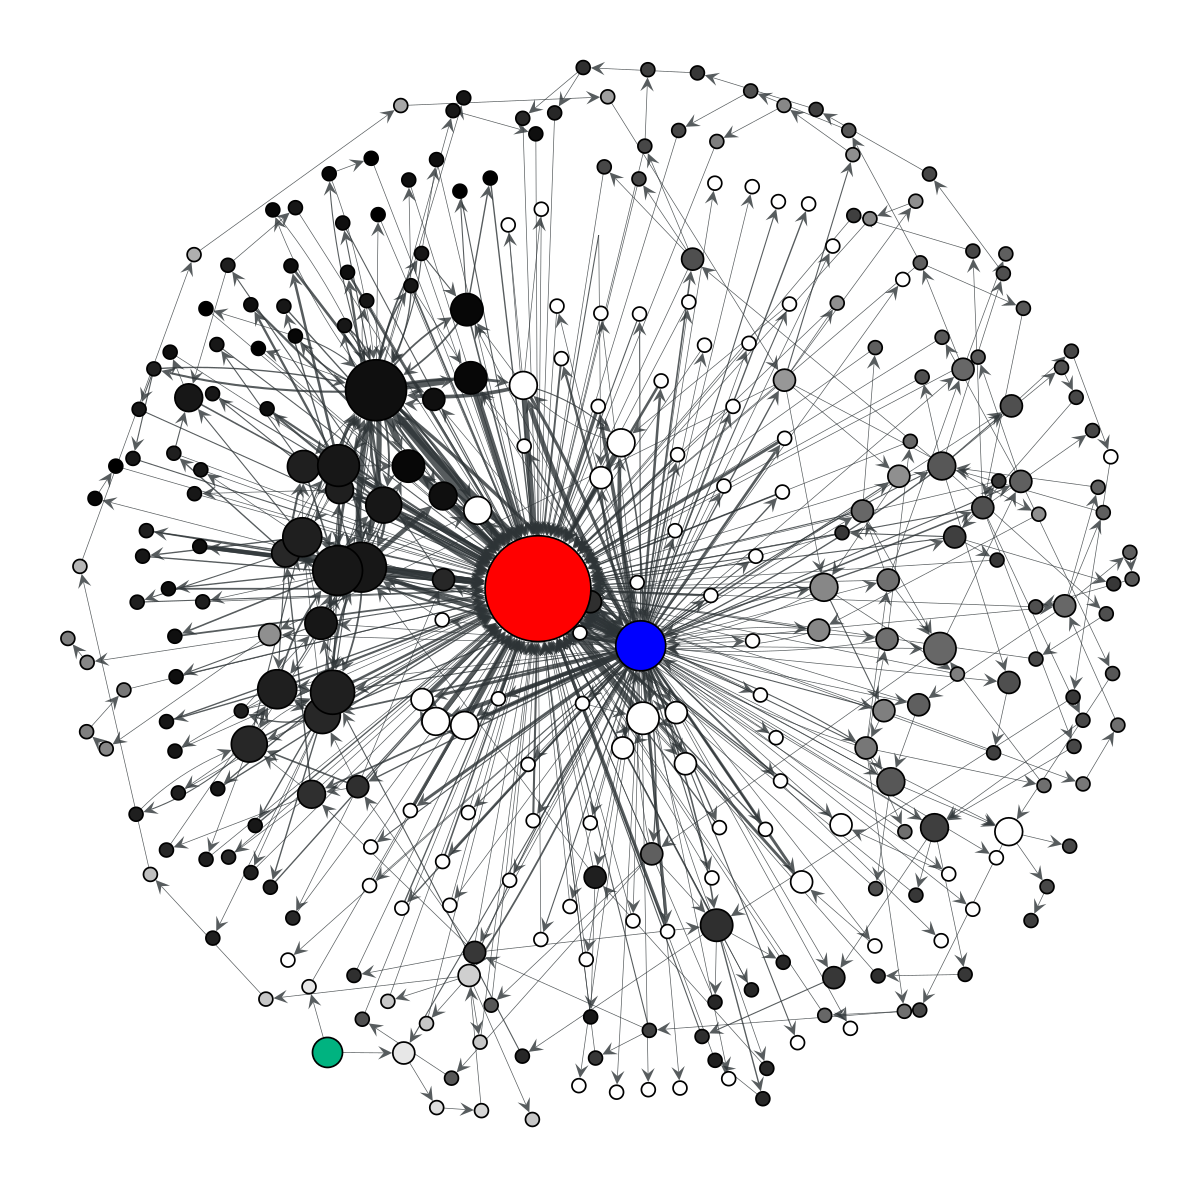

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7e3a0ef4b910, at 0x7e39853c2550>

In [ ]:
graph_draw(g, pos=pos, 
           vertex_size=vsize, 
           vertex_fill_color=v_color, vertex_color="k",# vertex_text="ciao",# vertex_font_size=10,
           edge_pen_width=esize, edge_marker_size=7, 
           bg_color="w")#, output="images/graph_example.png")

In [106]:
state = minimize_blockmodel_dl(g)

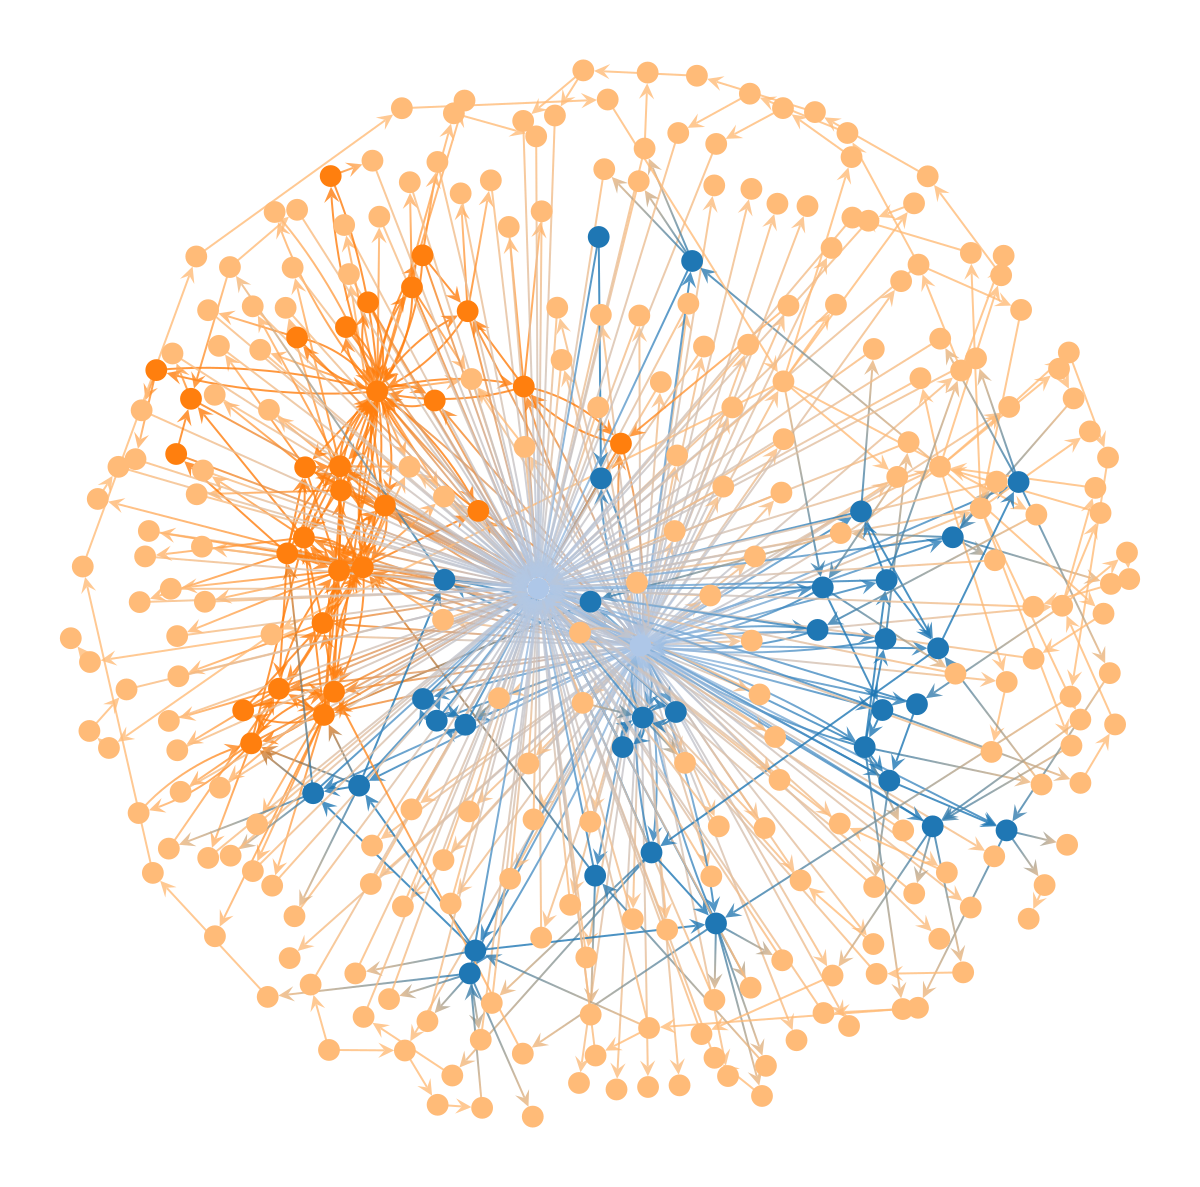

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7e3a0ef4b910, at 0x7e3985dcc7d0>

In [107]:
state.draw(pos=pos)